In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans, AgglomerativeClustering

In [10]:
image_path = "image.png" 
original_img = cv2.imread(image_path)

# OpenCV reads it as BGR so colors will look wrong
# cvtcolor changes to RGB
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# 3. Normalizing
img_data = original_img / 255.0

# 4. Reshaping
# Current shape: (Height, Width, 3)
# Target shape: (Height * Width, 3) 
h, w, c = img_data.shape
pixels = img_data.reshape(h * w, c)

print(f"Original shape: {original_img.shape}")
print(f"Flattened shape: {pixels.shape}") 
# If your image is 100x100, flattened shape will be (10000, 3)

Original shape: (804, 1276, 3)
Flattened shape: (1025904, 3)


Visualizing the image before processing...


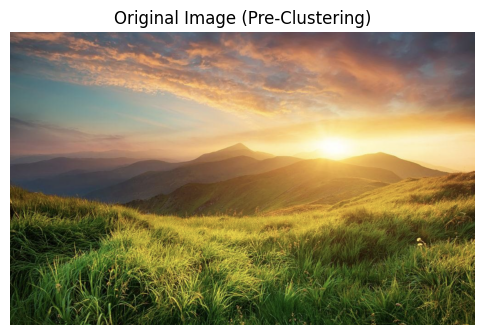

In [11]:
print("Visualizing the image before processing...")
plt.figure(figsize=(6, 6))
plt.imshow(original_img) 
plt.title("Original Image (Pre-Clustering)")
plt.axis('off') # Hide the x/y axis numbers
plt.show()

Running K-Means...


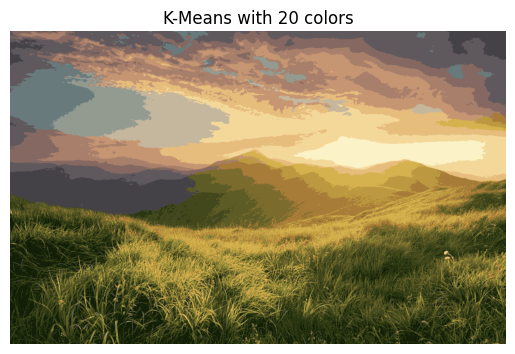

In [12]:

k = int(input("Enter number of clusters(K):")) 

print("Running K-Means...")
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(pixels)

labels = kmeans.predict(pixels)

centers = kmeans.cluster_centers_


new_pixels = centers[labels]

kmeans_image = new_pixels.reshape(h, w, c)

plt.imshow(kmeans_image)
plt.title(f"K-Means with {k} colors")
plt.axis('off')
plt.show()

Running Hierarchical Clustering...


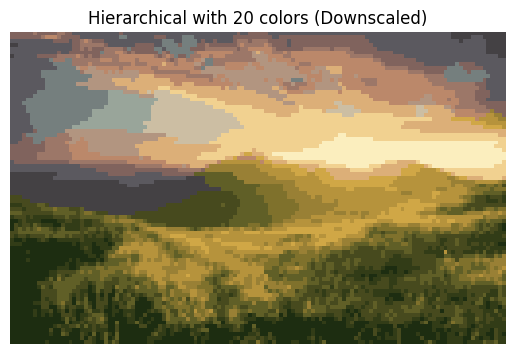

In [ ]:
print("Running Hierarchical Clustering...")

scale_percent = 10 
width = int(original_img.shape[1] * scale_percent / 100)
height = int(original_img.shape[0] * scale_percent / 100)
dim = (width, height)

small_img = cv2.resize(original_img, dim, interpolation=cv2.INTER_AREA)
small_img_data = small_img / 255.0

# Flatten the small image
sh, sw, sc = small_img_data.shape
small_pixels = small_img_data.reshape(sh * sw, sc)

agg = AgglomerativeClustering(n_clusters=k)
agg_labels = agg.fit_predict(small_pixels)

# We have to calculate the average color of each cluster ourselves.
agg_centers = np.zeros((k, 3))
for i in range(k):
    # Find all pixels belonging to cluster 'i' and take the mean
    cluster_points = small_pixels[agg_labels == i]
    if len(cluster_points) > 0:
        agg_centers[i] = cluster_points.mean(axis=0)

agg_new_pixels = agg_centers[agg_labels]
agg_image = agg_new_pixels.reshape(sh, sw, sc)

plt.imshow(agg_image)
plt.title(f"Hierarchical with {k} colors (Downscaled)")
plt.axis('off')
plt.show()